# Test TMOS Against SPICE

This notebook uses the [SPICE dataset](https://zenodo.org/record/10975225) to test the ability of [TMOS](github.com/openforcefield/tmos) to predict SMILES from XYZ for the subset of single-molecule SPICE datasets listed below.

All benchmark percentages are computed in this notebook from the current run and are printed in the Assess SMILES section.

- SPICE DES Monomers Single Points Dataset v1.1
- SPICE Dipeptides Single Points Dataset v1.3
- SPICE PubChem Set 1 Single Points Dataset v1.3
- SPICE PubChem Set 2 Single Points Dataset v1.3
- SPICE PubChem Set 3 Single Points Dataset v1.3
- SPICE PubChem Set 4 Single Points Dataset v1.3
- SPICE PubChem Set 5 Single Points Dataset v1.3
- SPICE PubChem Set 6 Single Points Dataset v1.3
- SPICE PubChem Set 7 Single Points Dataset v1.0
- SPICE PubChem Set 8 Single Points Dataset v1.0
- SPICE PubChem Set 9 Single Points Dataset v1.0
- SPICE PubChem Set 10 Single Points Dataset v1.0

## Prepare for SMILES Assessment

In [1]:
import subprocess
import re
from collections import defaultdict, Counter
from datetime import datetime, timezone
import hashlib
import os
import json

from rdkit import Chem
import numpy as np
from tqdm import tqdm
import h5py
from openff.units import unit
import periodictable as pt

import networkx as nx
from deepdiff import DeepDiff

import polars as pl

import tmos
from openff.toolkit import Molecule

SPICE_PATH = "/Users/jenniferclark/bin/back-to-school-jen/1_data/SPICE-2.0.1.hdf5"
BOHR_TO_ANGSTROM: float = (1.0 * unit.bohr).m_as(unit.angstrom)

def charged_element_signature(mol):
    """Count charged atoms by element and formal charge.

    Returns Counter[(atomic_num, formal_charge)] for non-neutral atoms.
    """
    return Counter(
        (atom.GetAtomicNum(), atom.GetFormalCharge())
        for atom in mol.GetAtoms()
        if atom.GetFormalCharge() != 0
    )

def is_resonance_equivalent_targeted(ref_mol, test_mol):
    """Return True only if test matches an RDKit resonance form of reference."""
    if ref_mol is None or test_mol is None:
        return False

    ref = Chem.Mol(ref_mol)
    test = Chem.Mol(test_mol)
    if ref is None or test is None:
        return False

    Chem.RemoveStereochemistry(ref)
    Chem.RemoveStereochemistry(test)

    # Keep this tolerant to partially sanitized inputs from upstream toolchains.
    for mol in (ref, test):
        try:
            Chem.SanitizeMol(mol)
        except Exception:
            pass

    if ref.GetNumAtoms() != test.GetNumAtoms():
        return False
    if Chem.GetFormalCharge(ref) != Chem.GetFormalCharge(test):
        return False

    try:
        flags = (
            Chem.ResonanceFlags.KEKULE_ALL
            | Chem.ResonanceFlags.ALLOW_CHARGE_SEPARATION
            | Chem.ResonanceFlags.UNCONSTRAINED_CATIONS
            | Chem.ResonanceFlags.UNCONSTRAINED_ANIONS
        )
        supplier = Chem.ResonanceMolSupplier(ref, flags)
    except Exception:
        return False

    if supplier is None:
        return False

    test_smiles = Chem.MolToSmiles(test, canonical=True)
    matched_any_form = False

    # RDKit can return None entries for some resonance candidates; skip safely.
    for idx in range(len(supplier)):
        ref_res = supplier[idx]
        if ref_res is None:
            continue
        matched_any_form = True
        if Chem.MolToSmiles(ref_res, canonical=True) == test_smiles:
            return True

    if not matched_any_form:
        return Chem.MolToSmiles(ref, canonical=True) == test_smiles

    return False

def format_error_bucket(err_key):
    """Create a readable label for structured error buckets."""
    if isinstance(err_key, tuple) and len(err_key) == 2:
        err_type, err_msg = err_key
        return f"{err_type}: {err_msg}"
    return str(err_key)

def check_nx_iso(mol1, mol2):
    nx_smiles = tmos.graph_mapping.mol_to_graph(mol1)
    nx_xyz    = tmos.graph_mapping.mol_to_graph(mol2)
    node_match = nx.algorithms.isomorphism.categorical_node_match("symbol", None)
    gm = nx.algorithms.isomorphism.GraphMatcher(nx_smiles, nx_xyz, node_match=node_match)
    return gm.is_isomorphic()
    
def check_offmol_iso(mol1, mol2):
    flag, _ = Molecule.are_isomorphic(
        Molecule.from_rdkit(mol1, allow_undefined_stereo=True, hydrogens_are_explicit=True), 
        Molecule.from_rdkit(mol2, allow_undefined_stereo=True, hydrogens_are_explicit=True),
        return_atom_map=True,
        aromatic_matching=True,
    #    formal_charge_matching=False,
    #    bond_order_matching=False,
        atom_stereochemistry_matching=False,
        bond_stereochemistry_matching=False,
    )
    return flag

def check_new_xyz_to_mol(record):
    offmol_cmiles = Molecule.from_mapped_smiles(record["smiles"], allow_undefined_stereo=True)
    rdmol_cmiles = offmol_cmiles.to_rdkit() 
    Chem.RemoveStereochemistry(rdmol_cmiles) 
    charge = sum([a.GetFormalCharge() for a in rdmol_cmiles.GetAtoms()])

    rdmol_tmos = tmos.build_rdmol.xyz_to_rdkit(
        record["symbols"], record["coords"][0], ignore_scale=True
    )
    rdmol_tmos = tmos.build_rdmol.determine_bonds(rdmol_tmos, charge=charge)
    Chem.RemoveStereochemistry(rdmol_tmos) 
    
    count_tmos = Counter([a.GetSymbol() for a in rdmol_tmos.GetAtoms()])
    count_cmiles = Counter([a.GetSymbol() for a in rdmol_cmiles.GetAtoms()])
    
    return {
        "smiles": record["smiles"], 
        "symbols": record["symbols"],
        "coord": record["coords"][0],
        "charge": charge,
        "rdmol_smiles": rdmol_cmiles,
        "rdmol_xyz": rdmol_tmos,
        "check_formula": len(DeepDiff(count_tmos, count_cmiles)) == 0,
        "iso_nx": check_nx_iso(rdmol_cmiles, rdmol_tmos),
        "iso_off": check_offmol_iso(rdmol_cmiles, rdmol_tmos),
    }

In [191]:
# Resonance checker fix: use mesomer-invariant hashing plus robust fallback checks.
from rdkit.Chem import rdMolHash


def _canonical_smiles_variants_for_resonance(mol):
    """Return canonical aromatic and kekule SMILES variants for a molecule."""
    if mol is None:
        return set()

    variants = set()
    m = Chem.Mol(mol)
    Chem.RemoveStereochemistry(m)

    for sanitize in (False, True):
        mm = Chem.Mol(m)
        if sanitize:
            try:
                Chem.SanitizeMol(mm)
            except Exception:
                pass
        variants.add(Chem.MolToSmiles(mm, canonical=True))
        try:
            variants.add(Chem.MolToSmiles(mm, canonical=True, kekuleSmiles=True))
        except Exception:
            pass

    return variants


def _mesomer_hash(mol):
    """Return RDKit mesomer hash (resonance-invariant) for a molecule copy."""
    m = Chem.Mol(mol)
    Chem.RemoveStereochemistry(m)
    try:
        Chem.SanitizeMol(m)
    except Exception:
        pass

    # Mesomer hash is defined on a valence representation and is robust for resonance checks.
    m_no_h = Chem.RemoveHs(m)
    return rdMolHash.MolHash(m_no_h, rdMolHash.HashFunction.Mesomer)


def _resonance_form_suppliers(ref_mol):
    """Yield resonance suppliers from multiple reference preparations."""
    flags = (
        Chem.ResonanceFlags.KEKULE_ALL
        | Chem.ResonanceFlags.ALLOW_CHARGE_SEPARATION
        | Chem.ResonanceFlags.UNCONSTRAINED_CATIONS
        | Chem.ResonanceFlags.UNCONSTRAINED_ANIONS
    )

    prepared_refs = []

    ref_raw = Chem.Mol(ref_mol)
    Chem.RemoveStereochemistry(ref_raw)
    prepared_refs.append(ref_raw)

    ref_sanitized = Chem.Mol(ref_mol)
    Chem.RemoveStereochemistry(ref_sanitized)
    try:
        Chem.SanitizeMol(ref_sanitized)
    except Exception:
        pass
    prepared_refs.append(ref_sanitized)

    seen = set()
    for candidate in prepared_refs:
        key = tuple(sorted(_canonical_smiles_variants_for_resonance(candidate)))
        if key in seen:
            continue
        seen.add(key)
        try:
            supplier = Chem.ResonanceMolSupplier(candidate, flags)
        except Exception:
            continue
        if supplier is not None:
            yield supplier


def is_resonance_equivalent_targeted(ref_mol, test_mol):
    """Return True only if test matches resonance-equivalent chemistry of reference."""
    if ref_mol is None or test_mol is None:
        return False

    ref = Chem.Mol(ref_mol)
    test = Chem.Mol(test_mol)
    if ref is None or test is None:
        return False

    Chem.RemoveStereochemistry(ref)
    Chem.RemoveStereochemistry(test)

    if ref.GetNumAtoms() != test.GetNumAtoms():
        return False
    if Chem.GetFormalCharge(ref) != Chem.GetFormalCharge(test):
        return False

    # Primary resonance criterion: mesomer-invariant identity.
    try:
        if _mesomer_hash(ref) == _mesomer_hash(test):
            return True
    except Exception:
        pass

    # Fallback criterion: explicit resonance-form enumeration and normalized SMILES matching.
    test_variants = _canonical_smiles_variants_for_resonance(test)
    if not test_variants:
        return False

    for supplier in _resonance_form_suppliers(ref):
        for idx in range(len(supplier)):
            ref_res = supplier[idx]
            if ref_res is None:
                continue
            if _canonical_smiles_variants_for_resonance(ref_res) & test_variants:
                return True

    return bool(_canonical_smiles_variants_for_resonance(ref) & test_variants)

In [2]:
SPICE_URL = "https://zenodo.org/record/10975225/files/SPICE-2.0.1.hdf5?download=1"

def sha256_file(file_path: str, chunk_size: int = 2**20) -> str:
    """Return SHA256 hex digest for a file."""
    h = hashlib.sha256()
    with open(file_path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

if not os.path.exists(SPICE_PATH):
    data_dir = os.path.dirname(SPICE_PATH)
    output_file = SPICE_PATH
    cmds = [
        f"mkdir -p {data_dir}",
        f"wget -O {output_file} {SPICE_URL}",
    ]
    for cmd in cmds:
        subprocess.run(
            cmd,
            check=True,
            shell=True,
        )
        
SPICE2_SOURCES: set[str] = {
    "SPICE DES Monomers Single Points Dataset v1.1",
    "SPICE Dipeptides Single Points Dataset v1.3",
    "SPICE PubChem Set 1 Single Points Dataset v1.3",
    "SPICE PubChem Set 2 Single Points Dataset v1.3",
    "SPICE PubChem Set 3 Single Points Dataset v1.3",
    "SPICE PubChem Set 4 Single Points Dataset v1.3",
    "SPICE PubChem Set 5 Single Points Dataset v1.3",
    "SPICE PubChem Set 6 Single Points Dataset v1.3",
    "SPICE PubChem Set 7 Single Points Dataset v1.0",
    "SPICE PubChem Set 8 Single Points Dataset v1.0",
    "SPICE PubChem Set 9 Single Points Dataset v1.0",
    "SPICE PubChem Set 10 Single Points Dataset v1.0",
}

## Assess SMILES

In [193]:
with h5py.File(SPICE_PATH) as spice:
    errors = defaultdict(list)
    outputs = []
    total_subset_records = 0

    run_metadata = {
        "spice_path": SPICE_PATH,
        "spice_url": SPICE_URL,
        "spice_sha256": sha256_file(SPICE_PATH),
        "subsets": sorted(SPICE2_SOURCES),
        "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "conformer_policy": "conformer_index_0",
        "conformer_policy_note": (
            "Conformer 0 is intentionally used."
        ),
    }

    for key, record in tqdm(spice.items(), desc="Extracting dataset", ncols=80):
        subset = record["subset"].asstr()[0]
        # Only extract the data if it's of the desired type
        if subset not in SPICE2_SOURCES:
            continue
        total_subset_records += 1

        smiles = record["smiles"].asstr()[0]
        dset = record["atomic_numbers"]
        if dset.dtype.kind in ("i", "u"):
            atomic_numbers = dset[()].tolist()
        else:
            s = dset.asstr()[0]
            atomic_numbers = [int(x) for x in re.findall(r"-?\d+", s)]

        # canonicalize to list of python ints
        atomic_numbers = [int(x) for x in atomic_numbers]
        elements = [pt.elements[z].symbol for z in atomic_numbers]

        n_conformers: int = record["conformations"].shape[0]
        assert len(record["dft_total_energy"]) == n_conformers
        coords = np.array([
            record["conformations"][i] * BOHR_TO_ANGSTROM
            for i in range(n_conformers)
        ], dtype=float)
        total_energy = record["dft_total_energy"][()].astype(float)
        data = {
            "smiles": smiles,
            "symbols": elements,
            "coords": coords,
            "total_energy": total_energy,
        }

        try:
            output = check_new_xyz_to_mol(data)
        except Exception as e:
            err_key = (type(e).__name__, str(e))
            errors[err_key].append({
                "data": data,
                "error_type": type(e).__name__,
                "error_message": str(e),
            })
        else:
            output["key"] = key

            # Targeted resonance test: only evaluate cases where graph matches but
            # strict OFF isomorphism fails, then compare to enumerated resonance forms.
            output["resonance_equivalent"] = (
                output["iso_nx"]
                and (not output["iso_off"])
                and is_resonance_equivalent_targeted(
                    output["rdmol_smiles"],
                    output["rdmol_xyz"],
                )
            )

            penalty_ref = tmos.build_rdmol.molecular_penalty(output["rdmol_smiles"])
            penalty_xyz = tmos.build_rdmol.molecular_penalty(output["rdmol_xyz"])
            output["smiles_is_worse"] = penalty_ref > penalty_xyz

            # Allow safe serialization and DataFrame storage
            output["coord"] = np.asarray(output["coord"]).tolist()

            outputs.append(output)

output_df = pl.DataFrame(outputs)

total_errors = sum(len(v) for v in errors.values())
successful_records = output_df.height

if total_subset_records != (successful_records + total_errors):
    raise RuntimeError(
        "Internal accounting mismatch: total_subset_records != successful_records + total_errors"
    )

run_metadata.update(
    {
        "total_subset_records": int(total_subset_records),
        "successful_records": int(successful_records),
        "error_records": int(total_errors),
    }
)

print(
    f"Records in selected SPICE subsets: {total_subset_records}; "
    f"successful: {successful_records}; exceptions: {total_errors}"
)

Extracting dataset:   1%|▏              | 1521/113986 [00:00<00:42, 2639.78it/s]/Users/jenniferclark/mamba/envs/architector/lib/python3.11/site-packages/openff/toolkit/topology/molecule.py:4341: MultipleComponentsInMoleculeWarning: RDKit Molecule passed to from_rdkit consists of more than one molecule, consider running rdkit.Chem.AllChem.GetMolFrags(rdmol, asMols=True) or splitting input SMILES at '.' to get separate molecules and pass them to from_rdkit one at a time. While this is supported for legacy reasons, OpenFF Molecule objects are not supposed to contain disconnected chemical graphs and this may result in undefined behavior later on. The OpenFF ecosystem is built to handle multiple molecules, but they should be in a Topology object, ex: top = Topology.from_molecules([mol1, mol2])
  molecule = toolkit.from_rdkit(
Extracting dataset:   2%|▎                | 1962/113986 [00:15<34:22, 54.32it/s]/Users/jenniferclark/mamba/envs/architector/lib/python3.11/site-packages/openff/toolkit

Records in selected SPICE subsets: 25607; successful: 25600; exceptions: 7


### Metrics Header

The printed rates below use a single denominator: all records in the listed SPICE subsets.

Conformer 0 is intentionally used in this notebook.

In [195]:
# Overview of how often the XYZ -> SMILES conversion was isomorphic
required_cols = {"check_formula", "iso_nx", "iso_off", "smiles_is_worse", "resonance_equivalent"}

def _pct_string(n: int, denom: int) -> str:
    if denom <= 0:
        return "0.0000%"
    pct = n / denom * 100.0
    if pct < 0.01:
        return f"{pct:.4f}%"
    if pct < 0.1:
        return f"{pct:.3f}%"
    return f"{pct:.2f}%"

if output_df.is_empty():
    print("output_df is empty.")
else:
    missing_cols = sorted(required_cols - set(output_df.columns))
    if missing_cols:
        print(f"output_df is missing required columns: {missing_cols}")
    else:
        denom_all = int(total_subset_records)
        success_n = int(output_df.height)
        error_n = int(sum(len(v) for v in errors.values()))

        print("Statistics denominator policy: all records in listed SPICE subsets.")
        print(
            "Conformer policy: conformer 0 only."
        )
        print(
            f"Denominator (all subset records): {denom_all}; "
            f"successful records: {success_n}; exceptions: {error_n}"
        )

        false_n = output_df.filter(pl.col("check_formula") == False).height
        print(
            f"check_formula == False: {false_n} / {denom_all} ({_pct_string(false_n, denom_all)})"
        )

        false_n = output_df.filter(pl.col("iso_nx") == False).height
        print(f"iso_nx == False: {false_n} / {denom_all} ({_pct_string(false_n, denom_all)})")

        false_n = output_df.filter((pl.col("iso_off") == False) & (pl.col("iso_nx") == True)).height
        print(
            f"iso_off == False with iso_nx == True: {false_n} / {denom_all} "
            f"({_pct_string(false_n, denom_all)})"
        )

        off_df = output_df.filter((pl.col("iso_off") == False) & (pl.col("iso_nx") == True))
        off_df = off_df.with_columns(
            (~pl.col("smiles_is_worse") & ~pl.col("resonance_equivalent")).alias("no_excuse")
        )

        def _print_bool_breakdown(df: pl.DataFrame, col: str, denom: int) -> None:
            if df.is_empty():
                print(f"   {col}: []")
                return

            denom_safe = max(int(denom), 1)
            summary = (
                df.group_by(col)
                .agg(pl.len().alias("n"))
                .sort(col)
            )
            msgs = [
                f"{row[col]}: {row['n']}; {_pct_string(int(row['n']), denom_safe)}"
                for row in summary.to_dicts()
            ]
            print(f"   {col}:", msgs)

        print("\nFor iso_off == False; iso_nx == True; percent of all subset records:")
        _print_bool_breakdown(off_df, "resonance_equivalent", denom_all)
        _print_bool_breakdown(off_df, "smiles_is_worse", denom_all)
        _print_bool_breakdown(off_df, "no_excuse", denom_all)

Statistics denominator policy: all records in listed SPICE subsets.
Conformer policy: conformer 0 only.
Denominator (all subset records): 25607; successful records: 25600; exceptions: 7
check_formula == False: 0 / 25607 (0.0000%)
iso_nx == False: 141 / 25607 (0.55%)
iso_off == False with iso_nx == True: 693 / 25607 (2.71%)

For iso_off == False; iso_nx == True; percent of all subset records:
   resonance_equivalent: ['False: 12; 0.047%', 'True: 681; 2.66%']
   smiles_is_worse: ['False: 231; 0.90%', 'True: 462; 1.80%']
   no_excuse: ['False: 692; 2.70%', 'True: 1; 0.0039%']


## Check Errored Structures

In [196]:
for err_key, values in errors.items():
    print(len(values), f"'{format_error_bucket(err_key)}'")

1 'RadicalsNotSupportedError: The OpenFF Toolkit does not currently support parsing molecules with S- and P-block radicals. Found 1 radical electrons on molecule O=S=O.[H]C1([H])[N]C([H])([H])C([H])([S+](=O)=O)C([H])([H])[N]C([H])([H])[N-]1.'
1 'AtomValenceException: Explicit valence for atom # 33 P, 7, is greater than permitted'
1 'RadicalsNotSupportedError: The OpenFF Toolkit does not currently support parsing molecules with S- and P-block radicals. Found 1 radical electrons on molecule [H][C]([H])C#CC([H])([H])OC([H])([H])C#CC([H])([H])[S].'
1 'RadicalsNotSupportedError: The OpenFF Toolkit does not currently support parsing molecules with S- and P-block radicals. Found 1 radical electrons on molecule O=S=O.[H]c1c([H])c([H])c(C23C(=O)C(c4c([H])c([H])c([H])c([H])c4[H])(C([H])([H])[N]C2([H])[H])C([H])([H])[N]C3([H])[H])c([H])c1[H].'
1 'RadicalsNotSupportedError: The OpenFF Toolkit does not currently support parsing molecules with S- and P-block radicals. Found 1 radical electrons on mo

In [197]:
# Output errored examples
input_list = []
output_list = []
for err_key, values in errors.items():
    err_label = format_error_bucket(err_key)
    for entry in values[:10]:
        value = entry["data"] if isinstance(entry, dict) else entry[0]

        coords = value["coords"] if len(value["coords"].shape) == 2 else value["coords"][0]
        rdmol = Chem.MolFromSmiles(value["smiles"], sanitize=False)
        charge = sum([a.GetFormalCharge() for a in rdmol.GetAtoms()])
        input_list.append({
            "symbols": value["symbols"],
            "coordinates": coords.tolist(), 
            "charge": charge,
        })
        output_list.append({"smiles": value["smiles"], "error": err_label})

for v in output_list:
    print(f"{v},")
with open("output_errored.json", "w") as f:
    json.dump(input_list, f, indent=2, default=str)

{'smiles': '[H:19][C:10]1([C:12]2([C:11]([N:6]3[C:9]([N:7]([S:14]2(=[O:3])=[O:4])[C:8]([N:5]1[S:13]3(=[O:1])=[O:2])([H:15])[H:16])([H:17])[H:18])([H:21])[H:22])[H:23])[H:20]', 'error': 'RadicalsNotSupportedError: The OpenFF Toolkit does not currently support parsing molecules with S- and P-block radicals. Found 1 radical electrons on molecule O=S=O.[H]C1([H])[N]C([H])([H])C([H])([S+](=O)=O)C([H])([H])[N]C([H])([H])[N-]1.'},
{'smiles': '[H:42][c:23]1[n:10][c:25]2[c:26]([c:24]([n:9]1)[N:27]([H:43])[H:44])[N:8]=[C:22]([N:28]2[C@@:30]([H:47])([C:20](=[O:2])[H:40])[O:12][C@:31]([H:48])([C:21](=[O:3])[H:41])[C:29]([H:45])([H:46])[P:34](=[O:6])([H:49])([O:17][H:38])([O:18][H:39])[O:19][P:33](=[O:5])([O:15][H:37])[O:16][P:32](=[O:4])([O:13][H:35])[O:14][H:36])[N:7]=[N+:11]=[N-:1]', 'error': 'AtomValenceException: Explicit valence for atom # 33 P, 7, is greater than permitted'},
{'smiles': '[H:11][C:7]1([C:1]#[C:3][C:9]([S:6][C:10]([C:4]#[C:2][C:8]([O:5]1)([H:13])[H:14])([H:17])[H:18])([H:15])[

In [198]:
# Let's visualize one of the errored structures
if not errors:
    raise ValueError("No errored structures were captured.")

first_error_key = next(iter(errors.keys()))
first_error_entry = errors[first_error_key][0]
tmp = first_error_entry["data"]
print(f"Inspecting error bucket: {format_error_bucket(first_error_key)}")

Inspecting error bucket: RadicalsNotSupportedError: The OpenFF Toolkit does not currently support parsing molecules with S- and P-block radicals. Found 1 radical electrons on molecule O=S=O.[H]C1([H])[N]C([H])([H])C([H])([S+](=O)=O)C([H])([H])[N]C([H])([H])[N-]1.


Reference molecule from the SMILES in SPICE dataset
Counter({'H': 9, 'C': 5, 'O': 4, 'N': 3, 'S': 2})


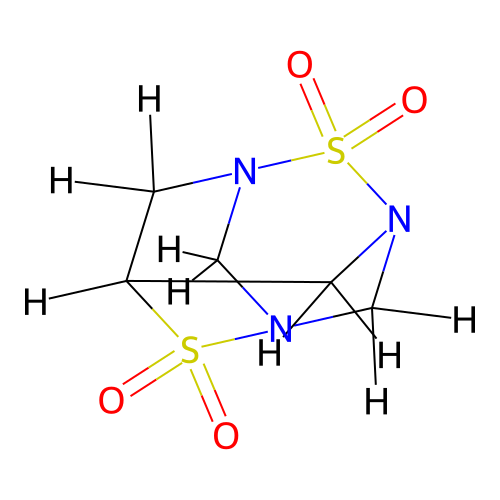

In [199]:
print("Reference molecule from the SMILES in SPICE dataset")
offmol_coord = Molecule.from_mapped_smiles(tmp["smiles"], allow_undefined_stereo=True)
rdmol = offmol_coord.to_rdkit()
print(Counter([a.GetSymbol() for a in rdmol.GetAtoms()]))
rdmol

In [200]:
print("Created molecule from the XYZ coordinates")
charge = sum(a.GetFormalCharge() for a in rdmol.GetAtoms())
rdmol = tmos.build_rdmol.xyz_to_rdkit(
        tmp["symbols"],
        tmp["coords"][0],
        ignore_scale=True,
    )
rdmol = tmos.build_rdmol.determine_bonds(rdmol, charge=charge)
tmos.utils.view3D(rdmol, label_idx=True)

Created molecule from the XYZ coordinates


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [201]:
from rdkit.Chem import AllChem

conf = rdmol.GetConformer()
pos = conf.GetPositions()

for target in [4, 5]:
    diff = pos[12] - pos[target]
    dist = np.linalg.norm(diff)
    print(f"Distance between atom 12 and atom {target}: {dist:.4f} Å")

Distance between atom 12 and atom 4: 1.7180 Å
Distance between atom 12 and atom 5: 1.6432 Å


## Check Graph Errors

In [202]:
# get xyz_issue examples
df_xyz = output_df.filter(
    (pl.col("iso_nx") == False)
)
print(len(df_xyz))

input_xyz = []
output_xyz = []
for value in df_xyz.to_dicts():
    coords = value["coord"]
    # allow both 2D and 3D (conformer-list) representations
    if coords and isinstance(coords[0], (list, tuple)) and coords and isinstance(coords[0][0], (list, tuple)):
        coords = coords[0]

    input_xyz.append({
        "key": value["key"],
        "symbols": value["symbols"],
        "coordinates": coords,
        "charge": value["charge"],
    })
    output_xyz.append({"smiles": value["smiles"], "key": value["key"]})

for v in output_xyz[:100]:
    print(f"{v},")
with open("output_xyz.json", "w") as f:
    json.dump(input_xyz[:100], f, indent=2, default=str)

141
{'smiles': '[H:27][c:5]1[c:8]([c:12]([c:16]([c:13]([c:9]1[H:31])[H:35])[C:23]([H:44])([H:45])[S:24](=[O:1])(=[O:2])[N:17]2[C:18]([C:20]([C:22]3([c:15]4[c:11]([c:7]([c:6]([c:10]([c:14]4[C:3](=[C:4]3[H:26])[H:25])[H:32])[H:28])[H:29])[H:33])[C:21]([C:19]2([H:38])[H:39])([H:42])[H:43])([H:40])[H:41])([H:36])[H:37])[H:34])[H:30]', 'key': '103915892'},
{'smiles': '[H:11][C:4]([H:12])([H:13])[S:7]([C:5]([H:14])([H:15])[H:16])([C:6]([H:17])([H:18])[C:3]([H:9])([H:10])[O:2][H:8])[I:1]', 'key': '103936110'},
{'smiles': '[H:18][c:8]1[c:7]([c:10]([c:9]([c:12]2[c:11]1[C:13]([C:15]([C:14]2([H:22])[H:23])([H:24])[H:25])([H:20])[H:21])[H:19])[O:5][P:16](=[O:2])([C:6](=[O:1])[O-:3])[O-:4])[H:17]', 'key': '103937032'},
{'smiles': '[O:1]=[C:6]([O:5][C:12]1([H:24])[C:10]([H:20])([H:21])[C:8]([H:16])([H:17])[C:7]([H:14])([H:15])[C:9]([H:18])([H:19])[C:11]1([H:22])[H:23])[P:13](=[O:2])([O-:3])[O-:4]', 'key': '103937033'},
{'smiles': '[H:22][C:9]([H:23])([H:24])[C:11]([H:28])([H:29])[O:2][C:13]([H:32])(

In [203]:
# Visually inspected exceptions:
skip_list = [
    # 5 coord P
    '56269918', '53785984', '49700569', '252639245', '175450798', '164151660', '160846871', '104162878', '103941369', '103941380', '104011880', '104026166', '104079126', '104121563', '104122545', '104131565', '104144137',
    # Different molecule that starting structure
    '135108278', '135198940', '135099703',
    # [NH][SO2][NH2]
    '378168652', '135240043', '136360040', '136360040', '135241126', '135241126', '104107971', '104107971', '104093208', '104016536', '384224122', '336951685', '312525585', '160855459', '163350562', '163368055', '164157438', '164158806',
    # [SO2][N] distance
    '8033812', '57299239', '49689429', '440733045', '440723447', '433931495', '433923774', '405264487', '405264486', '405261081', '405257794', '386403142', '385213482', '384585013', '384578165', '384573302', '381123119', '378153289', '374884571', '340094373', '336951952', '318471577', '311419635', '311419047', '252664450', '252662102', '252660238', '252660002', '252651090', '252650379', '252650113', '252644936', '252641878', '252639973', '252636071', '252618041', '252616474', '252081701', '164154406', '164035611', '163362086', '163347036', '163344864', '135310132', '135267246', '135261870', '135244861', '135238358', '135234830', '135233624', '135225634', '135215932', '135213839', '135211303', '135199339', '135197969', '135182358', '135178719', '135161485', '135116478', '135038861', '125088267', '104159745', '104142787', '104139950', '104131357', '104121161', '104115386', '104111867', '104106033', '104098126', '104093844', '104090281', '104076761', '103915892', '103996133', '104040870', '104043143', '104058255', '104058383',
    # Iodine bond distance
    '103936110',
    # P-C conjugated bond
    '103937032', '103937033', '135237885',
    # P-N
    '136353121', '135256999', '135240400', '135239583', '135223189', '135177073', '134975730', '135022724', '135077882', '135101512', '135116829', '135132480', '135139052', '135156454', '135156457', '135164350', '135171041', '135175945',
    # S-N
    '134980986',
    # S-C bond in 6-member ring
    '104032050',
    # SO2 - C
    '319493694',
    # N-S-* angle 5 member ring
    '135099123', '135100218', '135100852', '135138870', '135148523', 
    # C-S-C 6 member ring
    '242053812', 
    # N-N super conjugated
    '135236992',
    # N-O
    '135287704',
    # peroxide
    '136350920',
    # C-C????
    '252646112', '313069088', #'318490409',
]


tmp_dict = {x["key"]: x for x in input_xyz}
keys = [x for x in list(tmp_dict.keys()) if x not in skip_list]
#print(len(keys))
case = tmp_dict[keys[0]]
#case  = tmp_dict['252639245']
print(f"'{case['key']}'")
rdmol = tmos.build_rdmol.xyz_to_rdkit(
        case["symbols"],
        case["coordinates"],
        ignore_scale=True,
    )
rdmol = tmos.build_rdmol.determine_bonds(rdmol, charge=case["charge"])
tmos.utils.view3D(rdmol)

'318490409'


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Counter({'H': 24, 'C': 18, 'N': 4, 'O': 2})


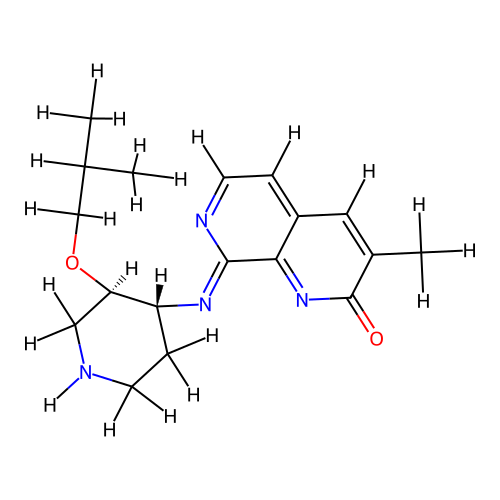

In [204]:
tmp_dict = {x["key"]: x for x in output_xyz}
offmol_coord = Molecule.from_mapped_smiles(tmp_dict[case['key']]["smiles"], allow_undefined_stereo=True)
rdmol = offmol_coord.to_rdkit()
print(Counter([a.GetSymbol() for a in rdmol.GetAtoms()]))
rdmol

## Check Bond Determination Failures

In [205]:
# get failures with no excuse examples (not resonant differences)
df_bo = output_df.filter(
    (pl.col("iso_off") == False)
    & (pl.col("iso_nx") == True)
    & (~pl.col("smiles_is_worse"))
    & (~pl.col("resonance_equivalent"))
)
print(len(df_bo))

input_bo = []
output_bo = []
for value in df_bo.to_dicts():
    coords = value["coord"]
    # allow both 2D and 3D (conformer-list) representations
    if coords and isinstance(coords[0], (list, tuple)) and coords and isinstance(coords[0][0], (list, tuple)):
        coords = coords[0]
    input_bo.append({
        "key": value["key"],
        "symbols": value["symbols"],
        "coordinates": coords,
        "charge": value["charge"],
    })
    output_bo.append({"smiles": value["smiles"], "key": value["key"],})

for v in output_bo[:100]:
    print(f"{v},")
with open("output_no_excuse.json", "w") as f:
    json.dump(input_bo[:100], f, indent=2, default=str)

1
{'smiles': '[O:1]=[C:6]([c:18]1[c:14]([H:33])[c:12]([H:31])[c:11]([H:30])[c:13]([H:32])[c:17]1[O-:3])[N:26](/[N:4]=[C:10](/[C:8]1=[C:9]([n+:28]2[c:22]([H:39])[c:20]([H:37])[c:24]3[c:19]([H:36])[c:15]([H:34])[c:16]([H:35])[c:21]([H:38])[c:25]3[c:23]2[H:40])[N:27]([H:42])[C:7](=[O:2])[S:5]1)[H:29])[H:41]', 'key': '164037624'},


In [206]:
tmp_dict = {x["key"]: x for x in input_bo}
keys = [x for x in list(tmp_dict.keys()) if x not in skip_list]
case = tmp_dict[keys[0]]
print(f"'{case['key']}'")
rdmol = tmos.build_rdmol.xyz_to_rdkit(
        case["symbols"],
        case["coordinates"],
        ignore_scale=True,
    )
rdmol = tmos.build_rdmol.determine_bonds(rdmol, charge=case["charge"])
tmos.utils.view3D(rdmol)

'164037624'


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

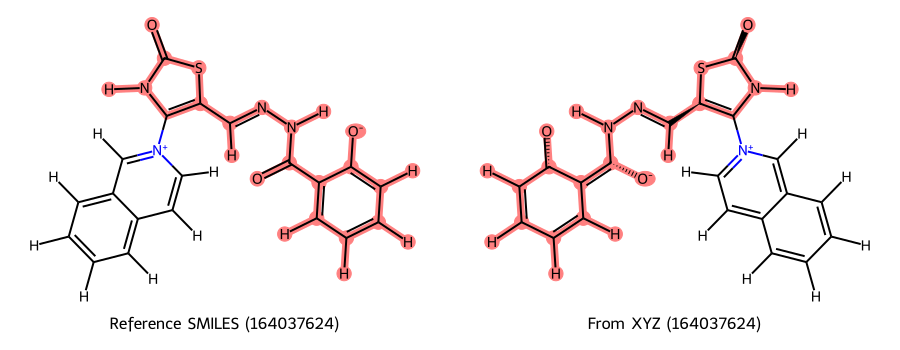

In [207]:
from rdkit.Chem import Draw, AllChem, rdFMCS

# Build both molecules for the current case key
input_by_key = {x["key"]: x for x in input_bo}
output_by_key = {x["key"]: x for x in output_bo}
k = case["key"]

# From XYZ
xyz_entry = input_by_key[k]
mol_xyz = tmos.build_rdmol.xyz_to_rdkit(
    xyz_entry["symbols"],
    xyz_entry["coordinates"],
    ignore_scale=True,
 )
mol_xyz = tmos.build_rdmol.determine_bonds(mol_xyz, charge=xyz_entry["charge"] )

# From mapped SMILES
mol_ref = Molecule.from_mapped_smiles(
    output_by_key[k]["smiles"], allow_undefined_stereo=True
).to_rdkit()

# 2D coordinates for side-by-side drawing
AllChem.Compute2DCoords(mol_ref)
AllChem.Compute2DCoords(mol_xyz)

# MCS-based difference highlighting
mcs = rdFMCS.FindMCS(
    [mol_ref, mol_xyz],
    atomCompare=rdFMCS.AtomCompare.CompareElements,
    bondCompare=rdFMCS.BondCompare.CompareOrderExact,
    ringMatchesRingOnly=True,
 )
patt = Chem.MolFromSmarts(mcs.smartsString)

ref_match = set(mol_ref.GetSubstructMatch(patt)) if patt is not None else set()
xyz_match = set(mol_xyz.GetSubstructMatch(patt)) if patt is not None else set()

ref_diff_atoms = [i for i in range(mol_ref.GetNumAtoms()) if i not in ref_match]
xyz_diff_atoms = [i for i in range(mol_xyz.GetNumAtoms()) if i not in xyz_match]

ref_diff_bonds = [
    b.GetIdx() for b in mol_ref.GetBonds()
    if b.GetBeginAtomIdx() in ref_diff_atoms or b.GetEndAtomIdx() in ref_diff_atoms
]
xyz_diff_bonds = [
    b.GetIdx() for b in mol_xyz.GetBonds()
    if b.GetBeginAtomIdx() in xyz_diff_atoms or b.GetEndAtomIdx() in xyz_diff_atoms
]

img = Draw.MolsToGridImage(
    [mol_ref, mol_xyz],
    molsPerRow=2,
    subImgSize=(450, 350),
    legends=[f"Reference SMILES ({k})", f"From XYZ ({k})"],
    highlightAtomLists=[ref_diff_atoms, xyz_diff_atoms],
    highlightBondLists=[ref_diff_bonds, xyz_diff_bonds],
)

img

Technically key=164037624 results in a resonance structure of itself, but RDKit doesn't detect that because of aromatic vs no aromatic detection.